# YouTube Anime Comment Analysis (Adapted from Reddit Notebook)

In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\luffy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\luffy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\luffy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv("Anime_Data_Youtube.csv")
df = df.dropna(subset=["Comment"])
df.head()
df.columns


Index(['Timestamp', 'ChannelID', 'Username', 'VideoID', 'Comment', 'Date',
       'Likes', 'subscriberCount'],
      dtype='object')

In [4]:
lemmatizer = WordNetLemmatizer()

# Custom YouTube stopwords
youtube_stopwords = set([
    'video', 'watch', 'channel', 'subscribe', 'like', 'comment', 
    'views', 'youtube', 'upload', 'link', 'click'
])
df = df.dropna(subset=['Comment'])

# Combine with standard stopwords
combined_stopwords = set(stopwords.words('english')).union(youtube_stopwords)

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in combined_stopwords and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

df['cleaned_comment'] = df['Comment'].apply(clean_text)
df.to_csv("cleaned_youtube_comments.csv", index=False)
df[['Comment', 'cleaned_comment']].head()

,Comment,cleaned_comment
0,Who's your favourite Straw Hat pirate and why?,who favourite straw hat pirate
1,"I love Usopp, I've always been a fan of underd...",love usopp ive always fan underdog character f...
2,I like franky because he’s such a silly guy :3,franky he silly guy
3,I’ve gotten to really love Jinbe and how long ...,ive gotten really love jinbe long took become ...
4,"I like zoro, because in spite of the yelling a...",zoro spite yelling simple driven he written su...


In [5]:
straw_hat_names = [
    "luffy", "zoro", "nami", "usopp", "sanji",
    "chopper", "robin", "franky", "brook", "jinbe"
]

def extract_words(text):
    return re.findall(r'\w+', text.lower())

comment_words = df['cleaned_comment'].fillna('').apply(extract_words).sum()
comment_counts = Counter(comment_words)
mention_counts = {name: comment_counts[name] for name in straw_hat_names}
mention_counts = dict(sorted(mention_counts.items(), key=lambda x: x[1], reverse=True))
mention_counts


{'luffy': 7436,
 'sanji': 5151,
 'zoro': 4183,
 'nami': 3837,
 'brook': 2739,
 'robin': 2677,
 'usopp': 2488,
 'chopper': 2094,
 'franky': 1161,
 'jinbe': 576}

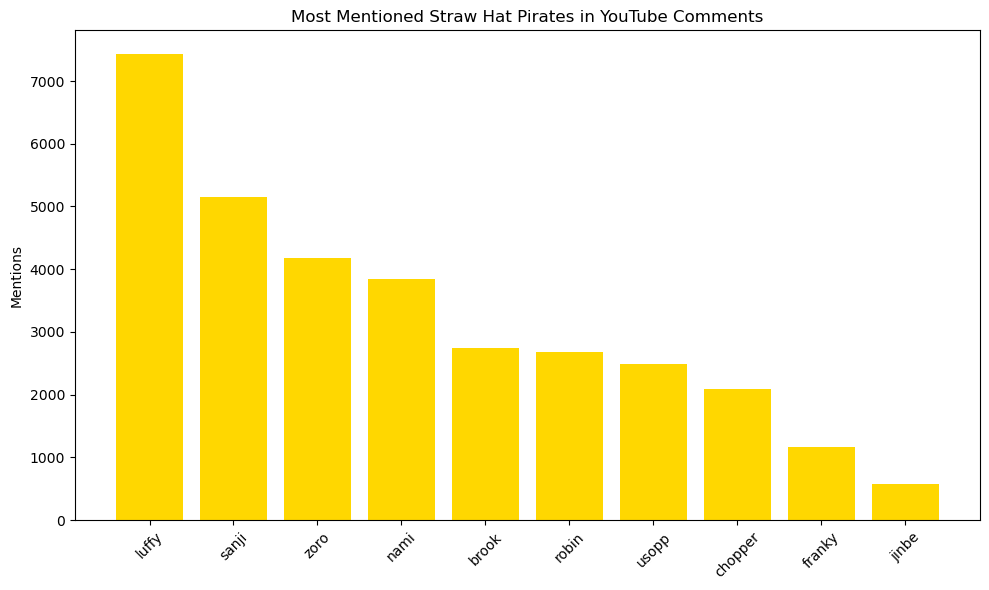

In [6]:
names, counts = zip(*mention_counts.items())

plt.figure(figsize=(10, 6))
plt.bar(names, counts, color='gold')
plt.title("Most Mentioned Straw Hat Pirates in YouTube Comments")
plt.ylabel("Mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [7]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df['sentiment_score'] = df['cleaned_comment'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
df['sentiment_label'] = df['sentiment_score'].apply(get_sentiment_label)
df.to_csv("youtube_comments_with_sentiment.csv", index=False)
df[['cleaned_comment', 'sentiment_label']].head()


,cleaned_comment,sentiment_label
0,who favourite straw hat pirate,neutral
1,love usopp ive always fan underdog character f...,positive
2,franky he silly guy,neutral
3,ive gotten really love jinbe long took become ...,positive
4,zoro spite yelling simple driven he written su...,negative


In [8]:
pirate_sentiment_counts = {}
for name in straw_hat_names:
    relevant = df[df['cleaned_comment'].str.contains(fr'\b{name}\b', na=False)]
    pirate_sentiment_counts[name] = relevant['sentiment_label'].value_counts().to_dict()
pirate_sentiment_counts


{'luffy': {'positive': 2816, 'negative': 1457, 'neutral': 910},
 'zoro': {'positive': 1475, 'negative': 893, 'neutral': 556},
 'nami': {'positive': 1505, 'negative': 866, 'neutral': 523},
 'usopp': {'positive': 1101, 'negative': 414, 'neutral': 325},
 'sanji': {'positive': 2140, 'negative': 1044, 'neutral': 610},
 'chopper': {'positive': 887, 'negative': 457, 'neutral': 421},
 'robin': {'positive': 1209, 'negative': 553, 'neutral': 356},
 'franky': {'positive': 544, 'negative': 190, 'neutral': 178},
 'brook': {'positive': 1146, 'negative': 527, 'neutral': 406},
 'jinbe': {'positive': 251, 'neutral': 114, 'negative': 98}}

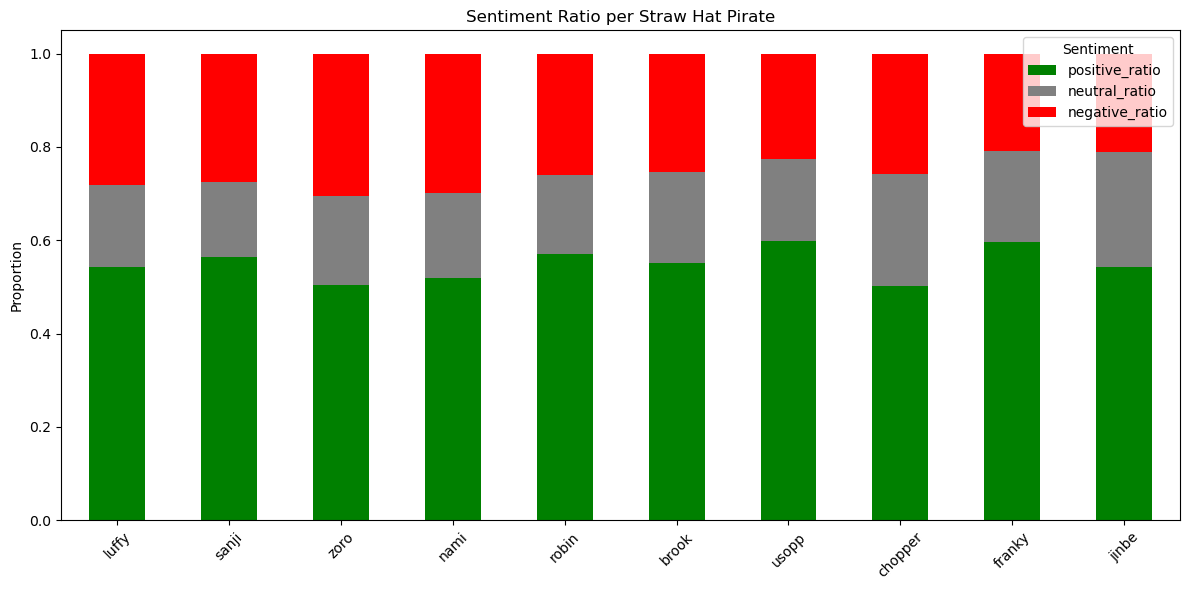

In [9]:
sentiment_df = pd.DataFrame(pirate_sentiment_counts).fillna(0).T

for sentiment in ['positive', 'negative', 'neutral']:
    if sentiment not in sentiment_df.columns:
        sentiment_df[sentiment] = 0

sentiment_df['total'] = sentiment_df.sum(axis=1)
sentiment_df['positive_ratio'] = sentiment_df['positive'] / sentiment_df['total']
sentiment_df['negative_ratio'] = sentiment_df['negative'] / sentiment_df['total']
sentiment_df['neutral_ratio'] = sentiment_df['neutral'] / sentiment_df['total']

sentiment_df_sorted = sentiment_df.sort_values(by='total', ascending=False)
sentiment_df_sorted[['positive_ratio', 'neutral_ratio', 'negative_ratio']].plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['green', 'gray', 'red']
)
plt.title("Sentiment Ratio per Straw Hat Pirate")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


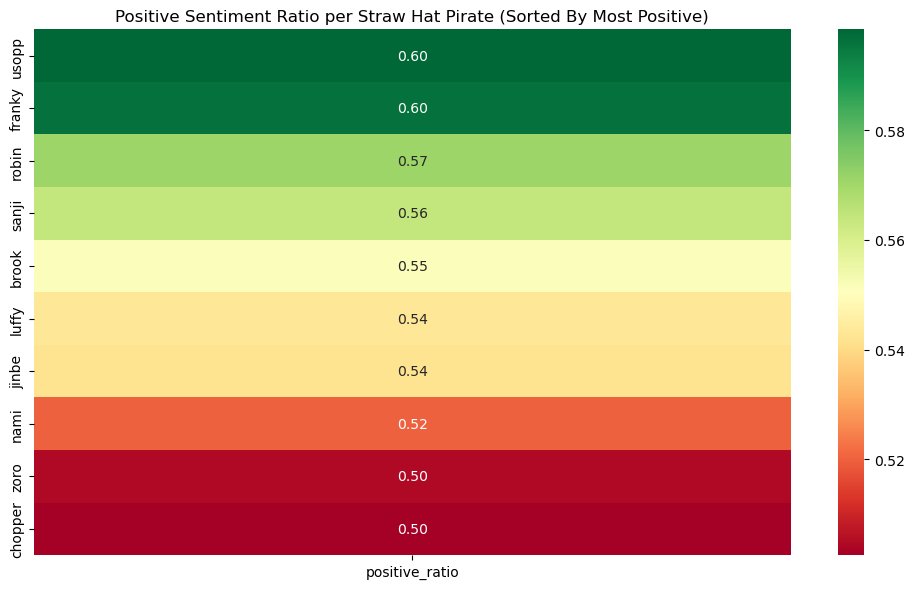

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# sort by highest positive ratio
sorted_by_positive = sentiment_df.sort_values(by='positive_ratio', ascending=False)

# plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    sorted_by_positive[['positive_ratio']],
    annot=True,
    cmap='RdYlGn',
    fmt=".2f"
)
plt.title("Positive Sentiment Ratio per Straw Hat Pirate (Sorted By Most Positive)")
plt.tight_layout()
plt.show()


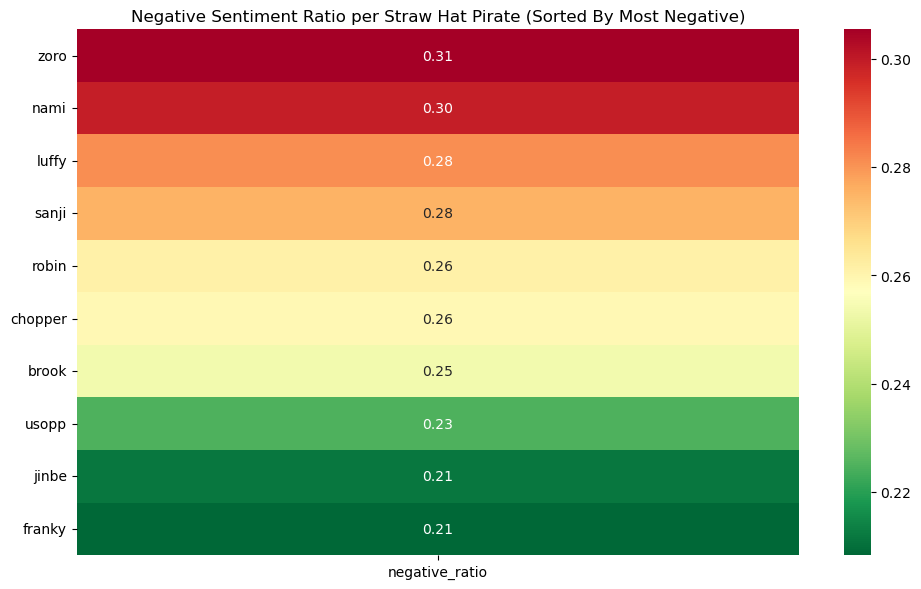

In [11]:
# sort by highest positive ratio
sorted_by_positive = sentiment_df.sort_values(by='negative_ratio', ascending=False)

# plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    sorted_by_positive[['negative_ratio']],
    annot=True,
    cmap='RdYlGn_r',
    fmt=".2f"
)
plt.title("Negative Sentiment Ratio per Straw Hat Pirate (Sorted By Most Negative)")
plt.tight_layout()
plt.show()


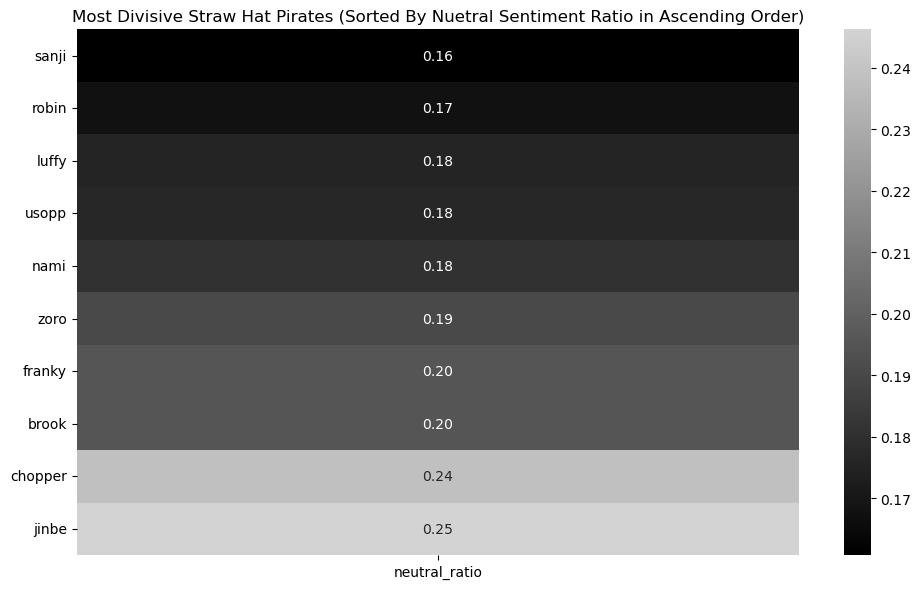

In [12]:
from matplotlib.colors import LinearSegmentedColormap

# Create custom black-to-grey colormap
black_to_grey = LinearSegmentedColormap.from_list("black_grey", ["black", "lightgrey"])

# sort by highest positive ratio
sorted_by_positive = sentiment_df.sort_values(by='neutral_ratio', ascending=True)

# plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    sorted_by_positive[['neutral_ratio']],
    annot=True,
    cmap=black_to_grey,
    fmt=".2f"
)
plt.title("Most Divisive Straw Hat Pirates (Sorted By Nuetral Sentiment Ratio in Ascending Order)")
plt.tight_layout()
plt.show()


In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

df = pd.read_csv("cleaned_youtube_comments.csv")
stop_words = stopwords.words('english')

straw_hat_names = ["luffy", "zoro", "nami", "usopp", "sanji", "chopper", "robin", "franky", "brook", "jinbe"]

def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx + 1}:")
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(", ".join(top_words))

for pirate in straw_hat_names:
    pirate_comments = df[df['cleaned_comment'].str.contains(fr'\b{pirate}\b', na=False)]
    texts = pirate_comments['cleaned_comment'].dropna().tolist()

    if len(texts) < 10:
        print(f"\n{pirate.capitalize()} - not enough comments for topic modeling.")
        continue

    print(f"\nTopics for {pirate.capitalize()}")
    vectorizer = CountVectorizer(tokenizer=word_tokenize, stop_words=stop_words)
    dtm = vectorizer.fit_transform(texts)
    lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
    lda_model.fit(dtm)
    feature_names = vectorizer.get_feature_names_out()
    display_topics(lda_model, feature_names, no_top_words=5)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\luffy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\luffy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Topics for Luffy


C:\Users\luffy\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\luffy\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'might', 'must', "n't", 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(



Topic 1:
luffy, one, character, sanji, crew

Topic 2:
luffy, zoro, haki, kaido, stronger

Topic 3:
luffy, nami, hat, one, straw

Topics for Zoro

Topic 1:
zoro, sanji, luffy, nami, one

Topic 2:
zoro, luffy, haki, kaido, stronger

Topic 3:
zoro, luffy, sanji, would, one

Topics for Nami

Topic 1:
nami, luffy, crew, one, people

Topic 2:
nami, luffy, sanji, one, zoro

Topic 3:
nami, one, character, shes, piece

Topics for Usopp

Topic 1:
usopp, luffy, god, crew, would

Topic 2:
usopp, character, one, luffy, elbaf

Topic 3:
luffy, usopp, nami, sanji, zoro

Topics for Sanji

Topic 1:
sanji, one, character, love, luffy

Topic 2:
sanji, character, love, woman, much

Topic 3:
sanji, zoro, luffy, nami, usopp

Topics for Chopper

Topic 1:
chopper, arc, one, luffy, best

Topic 2:
chopper, luffy, robin, zoro, nami

Topic 3:
chopper, one, love, piece, character

Topics for Robin

Topic 1:
robin, luffy, one, nami, chopper

Topic 2:
robin, nami, luffy, arc, one

Topic 3:
robin, character, one, san

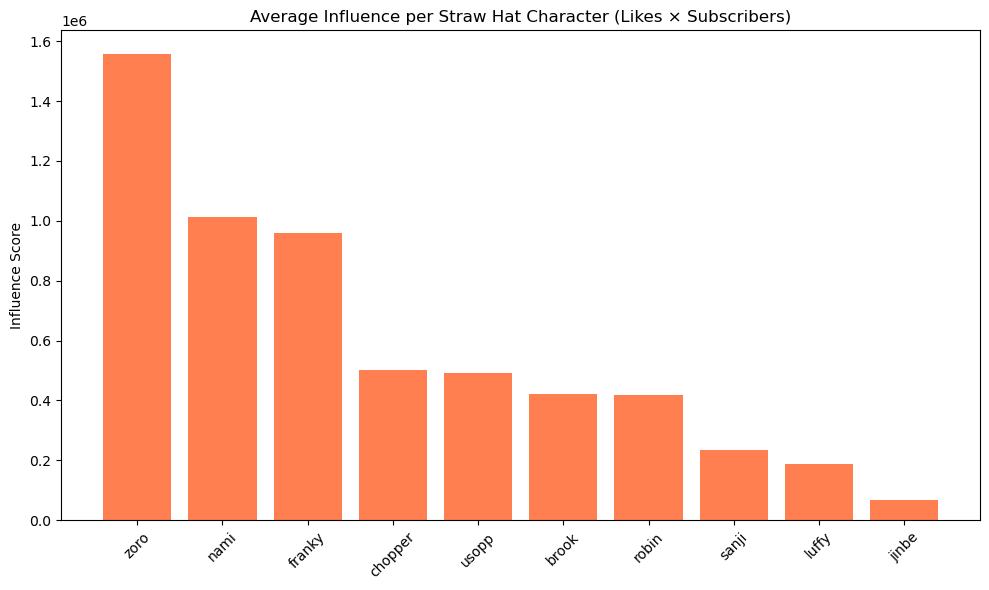

In [14]:
df['influence'] = df['Likes'] * df['subscriberCount']
avg_influence = {}

for name in straw_hat_names:
    relevant = df[df['cleaned_comment'].str.contains(fr'\b{name}\b', na=False)]
    avg_influence[name] = relevant['influence'].mean() if not relevant.empty else 0

avg_influence = dict(sorted(avg_influence.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 6))
plt.bar(avg_influence.keys(), avg_influence.values(), color='coral')
plt.title("Average Influence per Straw Hat Character (Likes × Subscribers)")
plt.ylabel("Influence Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


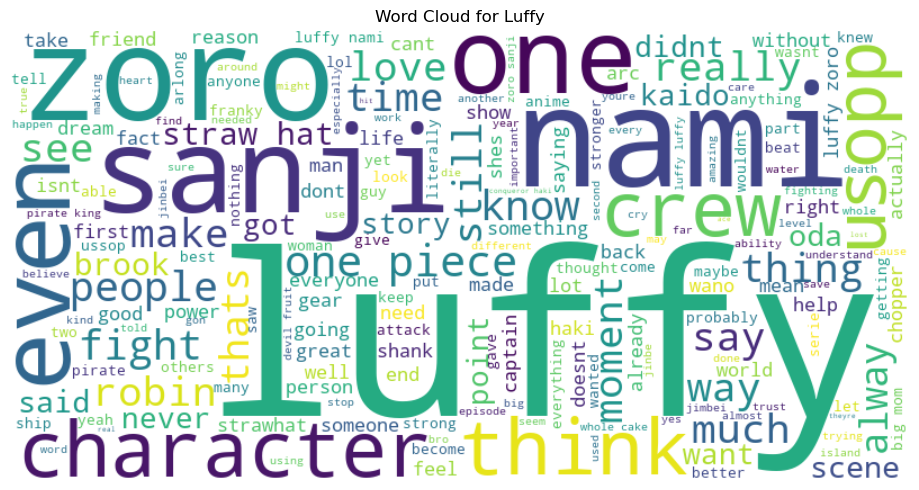

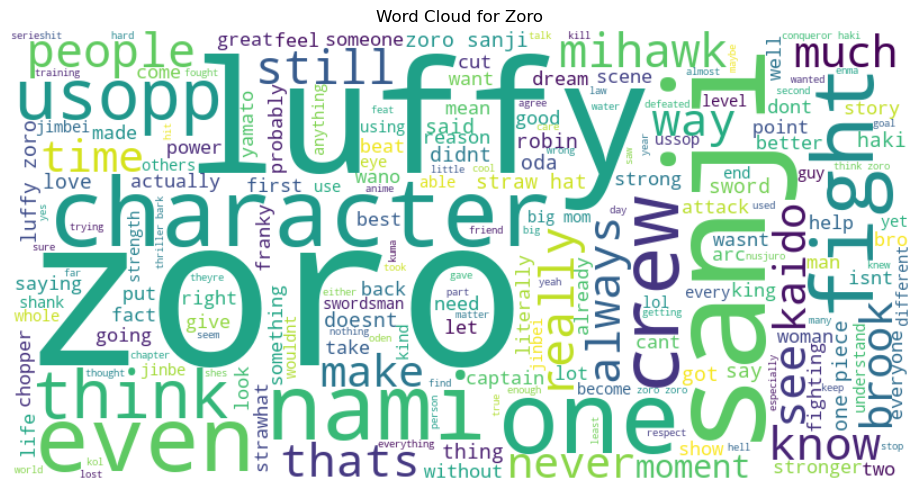

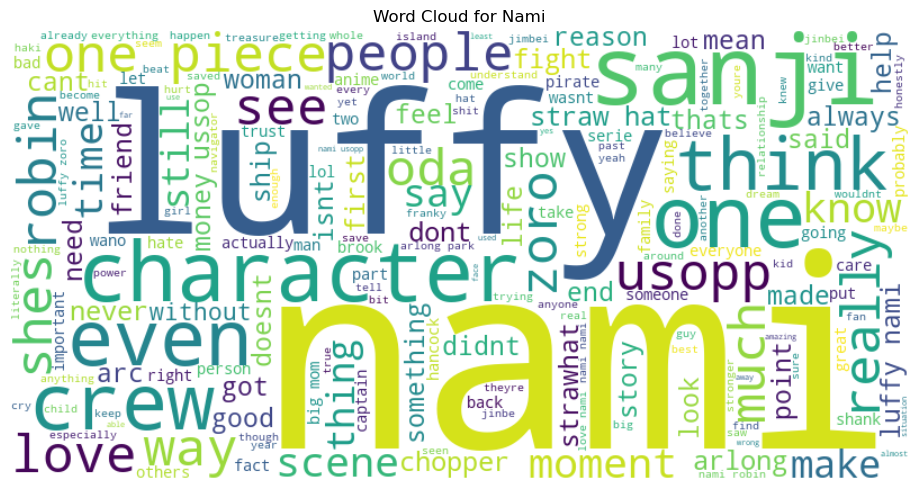

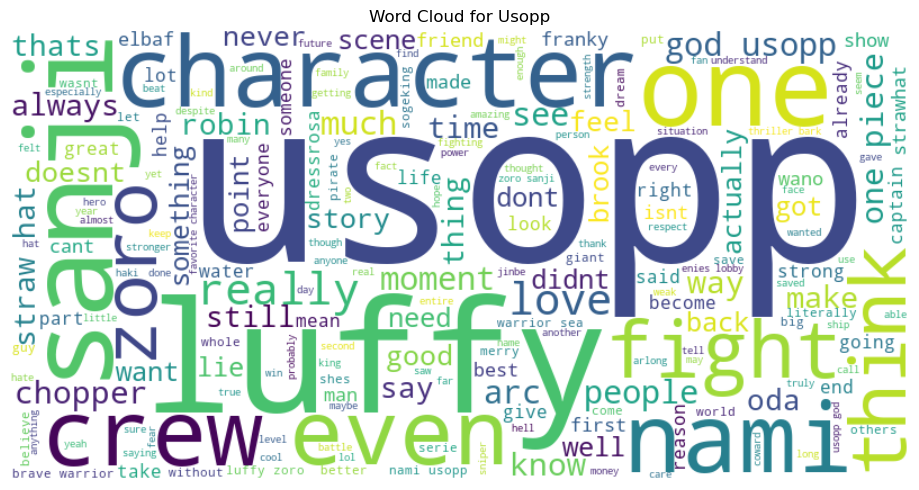

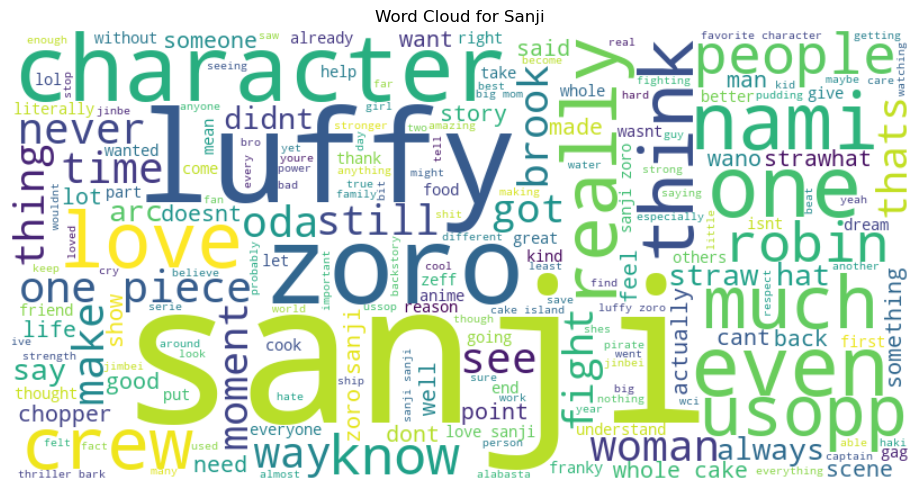

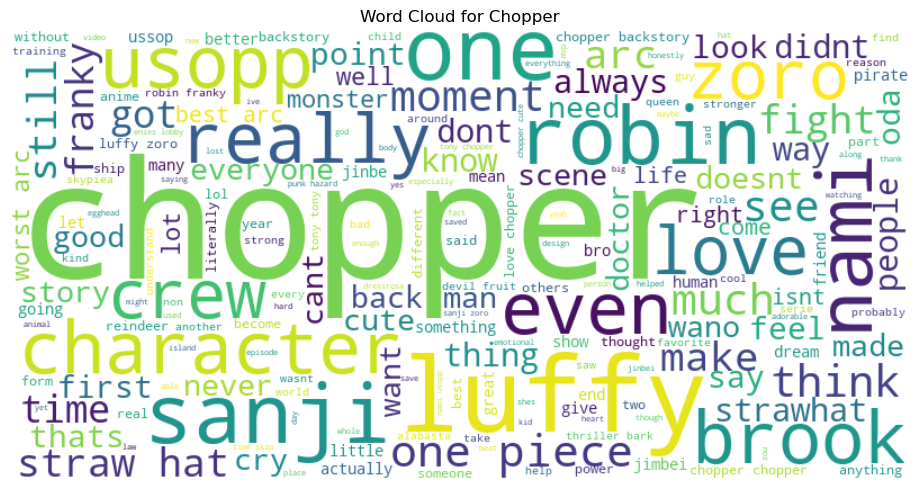

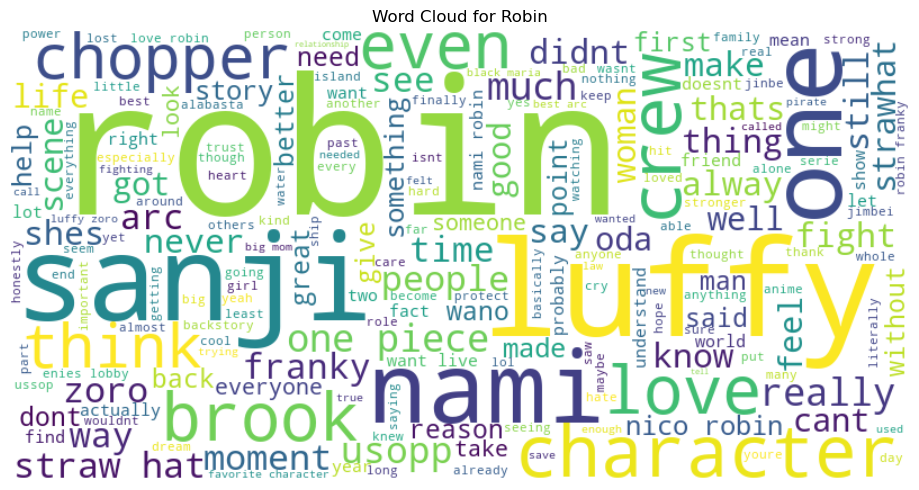

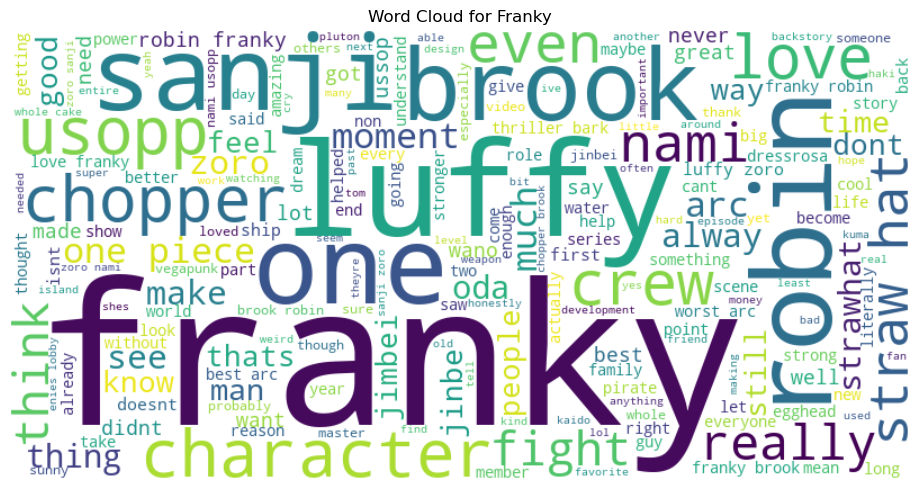

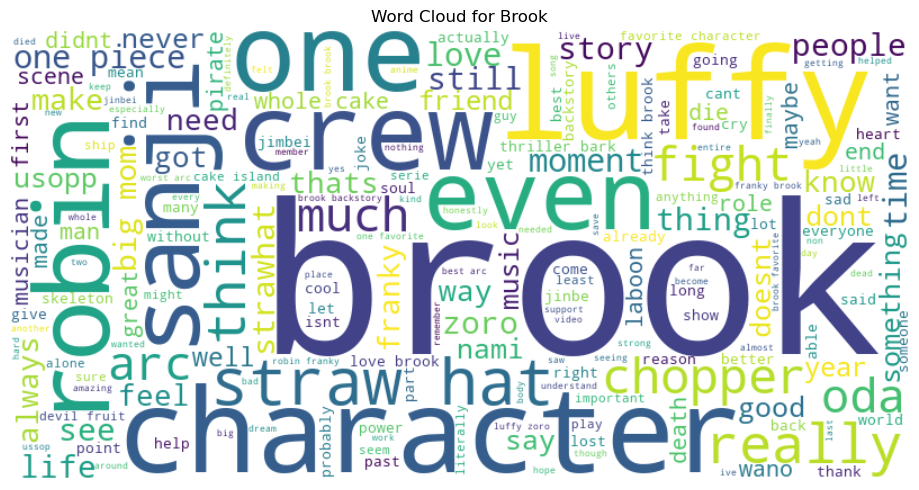

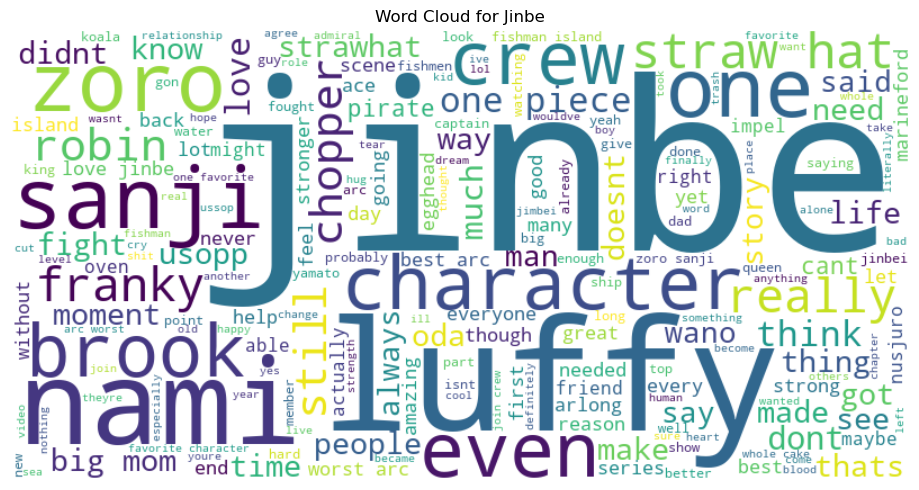

In [15]:
for pirate in straw_hat_names:
    pirate_comments = df[df['cleaned_comment'].str.contains(fr'\b{pirate}\b', na=False)]
    text = ' '.join(pirate_comments['cleaned_comment'].dropna().tolist())
    if len(text) < 50:
        print(f"{pirate.capitalize()} - Not enough data")
        continue

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for {pirate.capitalize()}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [16]:
from collections import defaultdict, Counter

# Define Straw Hat Pirates
straw_hat_names = [
    "luffy", "zoro", "nami", "usopp", "sanji",
    "chopper", "robin", "franky", "brook", "jinbe"
]

# Co-mention dictionary
co_mentions = defaultdict(Counter)

# Use YouTube cleaned comments (no titles in YouTube)
comments_df = df.copy()  # assuming df already loaded and cleaned
all_texts = comments_df['cleaned_comment'].dropna().astype(str)

# Loop through combined text
for text in all_texts:
    mentioned = [name for name in straw_hat_names if f' {name} ' in f' {text.lower()} ']
    for name in mentioned:
        for other in mentioned:
            if name != other:
                co_mentions[name][other] += 1

# Collect top co-mention for each character
top_pairs = []
for name in straw_hat_names:
    top = co_mentions[name].most_common(1)
    if top:
        top_pairs.append((name, top[0][0], top[0][1]))

# Sort by mention count
top_pairs_sorted = sorted(top_pairs, key=lambda x: x[2], reverse=True)

# Display results
print("Top Co-Mention for each Straw Hat (sorted by mentions):")
for name, other, count in top_pairs_sorted:
    print(f"{name.capitalize()} → {other.capitalize()} ({count} mentions)")


Top Co-Mention for each Straw Hat (sorted by mentions):
Luffy → Nami (1046 mentions)
Nami → Luffy (1046 mentions)
Zoro → Luffy (966 mentions)
Sanji → Zoro (851 mentions)
Robin → Luffy (415 mentions)
Usopp → Luffy (389 mentions)
Brook → Robin (270 mentions)
Chopper → Robin (254 mentions)
Franky → Robin (224 mentions)
Jinbe → Luffy (92 mentions)


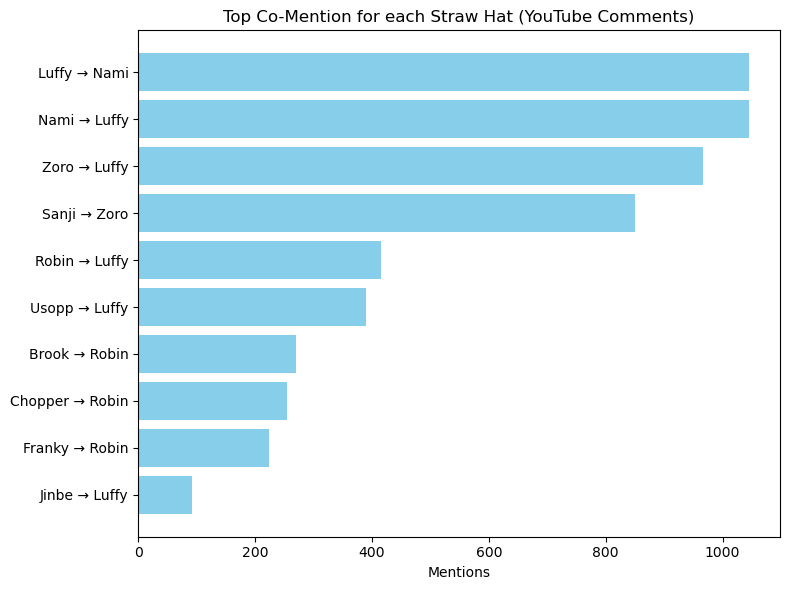

In [17]:
import matplotlib.pyplot as plt

# Convert to label + count
labels = [f"{a.capitalize()} → {b.capitalize()}" for a, b, _ in top_pairs_sorted]
counts = [c for _, _, c in top_pairs_sorted]

# Plot horizontal bar chart
plt.figure(figsize=(8, 6))
plt.barh(labels, counts, color='skyblue')
plt.xlabel("Mentions")
plt.title("Top Co-Mention for each Straw Hat (YouTube Comments)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


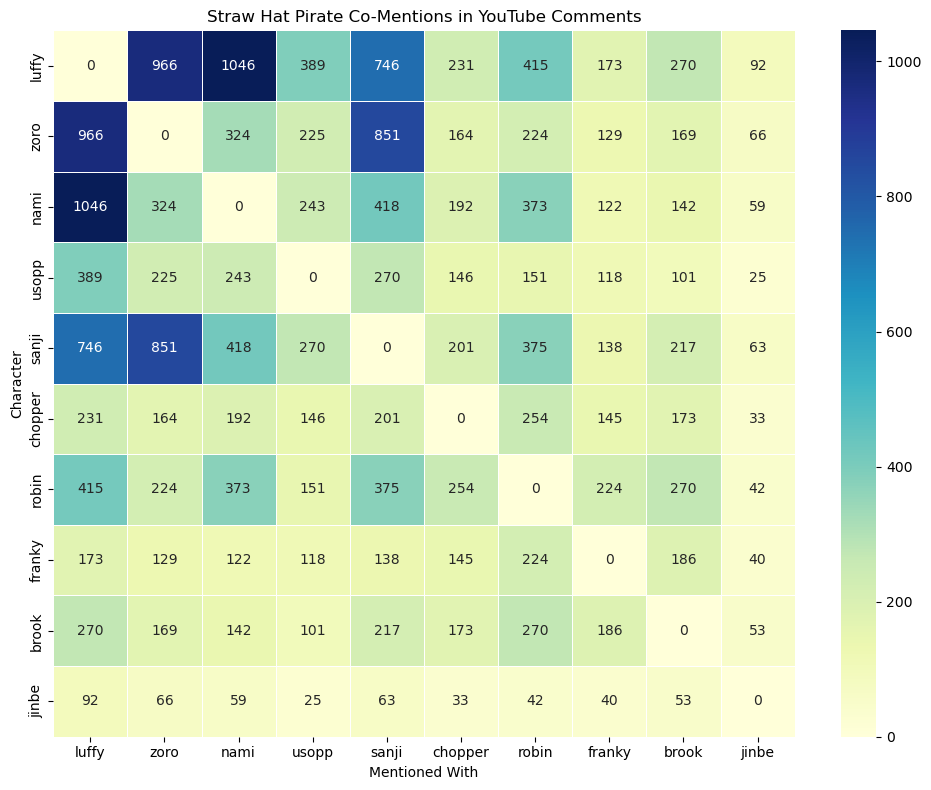

In [18]:
import seaborn as sns

# Create symmetrical matrix
co_matrix = pd.DataFrame(co_mentions).fillna(0).astype(int)
co_matrix = co_matrix.reindex(index=straw_hat_names, columns=straw_hat_names).fillna(0)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)
plt.title("Straw Hat Pirate Co-Mentions in YouTube Comments")
plt.xlabel("Mentioned With")
plt.ylabel("Character")
plt.tight_layout()
plt.show()
